# Task 3 — Conditional GAN (CGAN) on MNIST

We extend the Task 1 Vanilla GAN into a Conditional GAN. Both the Generator and Discriminator
receive a class label as a second input, enabling targeted generation of a chosen digit 0–9.

## Conditioning mechanism

A CGAN conditions both networks on auxiliary information $y$ (here, a digit class label 0–9):

- **Generator** $G(z, y)$: concatenates a noise vector $z$ with a one-hot label $y$ and generates a fake image for that class.
- **Discriminator** $D(x, y)$: concatenates an image $x$ with a one-hot label $y$ and scores whether the pair $(x, y)$ is real.

One-hot encoding is applied inside each model's `forward()` — the dataloader provides integer
labels as usual, and `F.one_hot` converts them internally. Loss uses `BCEWithLogitsLoss` on raw
logits (no sigmoid in D), matching Tasks 1 and 2 for numerical stability and AMP compatibility.

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import global_config as gc
from utils import device_check, show_cgan_images, build_model_name
from GAN import ConditionalGenerator, ConditionalDiscriminator, train_GAN

In [2]:
LOG_WANDB = True
SEED = 1

# Device setup
device = device_check()

# Reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
    PIN_MEMORY = True
    NUM_WORKERS = 8
    PERSISTENT_WORKERS = True
    PREFETCH_FACTOR = 4
else:
    PIN_MEMORY = False
    NUM_WORKERS = 0
    PERSISTENT_WORKERS = False
    PREFETCH_FACTOR = 2

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


## Load MNIST dataset

In [3]:
BATCH_SIZE = 256

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root=gc.DATA_DIR,
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
)

print("Number of training samples:", len(train_dataset))
print("Number of batches per epoch:", len(train_loader))

Number of training samples: 60000
Number of batches per epoch: 234


## Visualize a few real images

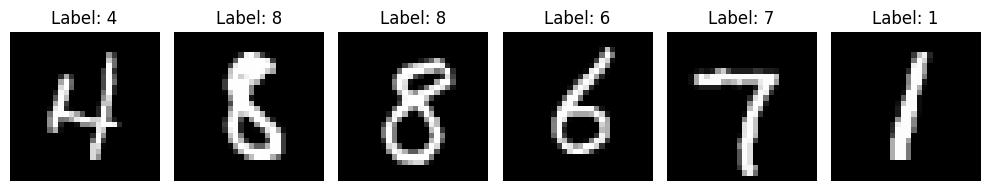

In [4]:
real_images, real_labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(real_images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {real_labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Initialize models

In [5]:
LATENT_DIM = 100
NUM_CLASSES = 10
G_HIDDEN_DIM = 128
D_HIDDEN_DIM = 128
IMAGE_DIM = 28 * 28

G = ConditionalGenerator(
    z_dim=LATENT_DIM,
    h_dim=G_HIDDEN_DIM,
    x_dim=IMAGE_DIM,
    num_classes=NUM_CLASSES,
).to(device)

D = ConditionalDiscriminator(
    x_dim=IMAGE_DIM,
    h_dim=D_HIDDEN_DIM,
    num_classes=NUM_CLASSES,
).to(device)

print(G)
print()
print(D)

ConditionalGenerator(
  (fc1): Linear(in_features=110, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=784, bias=True)
)

ConditionalDiscriminator(
  (fc1): Linear(in_features=794, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


## Define optimizers

In [6]:
LR = 1e-3
BETAS = (0.9, 0.999)

g_optimizer = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
d_optimizer = optim.Adam(D.parameters(), lr=LR, betas=BETAS)

## Train the Conditional GAN

In [7]:
EPOCHS = 1500

config = {
    "epochs": EPOCHS,
    "latent_dim": LATENT_DIM,
    "image_dim": IMAGE_DIM,
    "num_classes": NUM_CLASSES,
    "batch_size": BATCH_SIZE,
    "g_lr": LR,
    "d_lr": LR,
    "g_hidden_dim": G_HIDDEN_DIM,
    "d_hidden_dim": D_HIDDEN_DIM,
    "betas": BETAS,
    "optimizer": "Adam",
    "dataset": "MNIST",
    "model": "Conditional GAN",
    "seed": SEED,
}

wandb_kwargs = dict(
    entity=gc.WANDB_ENTITY,
    project=gc.WANDB_PROJECT,
    name="Conditional GAN",
    tags=["Task 3", "MNIST", "CGAN"],
    dir=str(gc.WANDB_DIR),
    config=config,
    mode="online" if LOG_WANDB else "disabled",
)

train_GAN(
    G=G,
    D=D,
    train_loader=train_loader,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    config=config,
    device=device,
    wandb_kwargs=wandb_kwargs,
    conditional=True,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: oscar-engelmark (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training:   0%|          | 0/1500 [00:00<?, ?ep/s]

D_fake_loss,▁▆▆▇▇██████████▇▇▇▇▇▆▆▆▆▆▆▆▆▆▆▅▅▅▅▅▅▅▅▅▅
D_loss,▁▇▇███████▇▇▇▇▇▇▇▇▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆
D_real_loss,▃▅▆▇██████████▇▇▇▇▆▆▆▅▅▄▄▃▃▂▂▂▂▂▁▁▁▂▂▁▁▁
G_loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
epoch,▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇███
D_fake_loss,0.28163
D_loss,0.62407
D_real_loss,0.34244
G_loss,2.42768
epoch,1500


## Save trained models

In [8]:
checkpoint_name = build_model_name(config, task_name="task3", file_ext="pt")
checkpoint_path = gc.MODELS_DIR / checkpoint_name

torch.save({
    "generator_state_dict": G.state_dict(),
    "discriminator_state_dict": D.state_dict(),
    "g_optimizer_state_dict": g_optimizer.state_dict(),
    "d_optimizer_state_dict": d_optimizer.state_dict(),
    "config": config,
}, checkpoint_path)

print(f"Checkpoint saved to: {checkpoint_path}")

Checkpoint saved to: /root/D7047E/Lab2/models/task3_model-Conditional_GAN_data-MNIST_ep-1500_bs-256_glr-0.001_dlr-0.001_gh-128_dh-128_seed-1_20260422_132334.pt


## Display final generated samples

Generate a 4×4 grid of samples for each digit class 0–9.

Digit 0


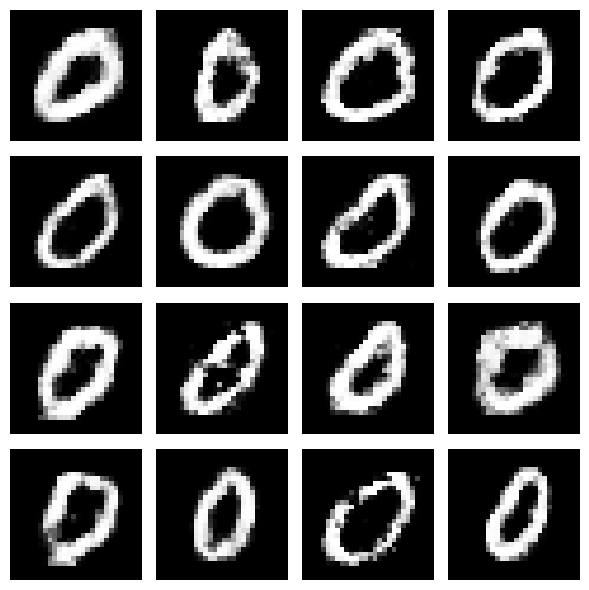

Digit 1


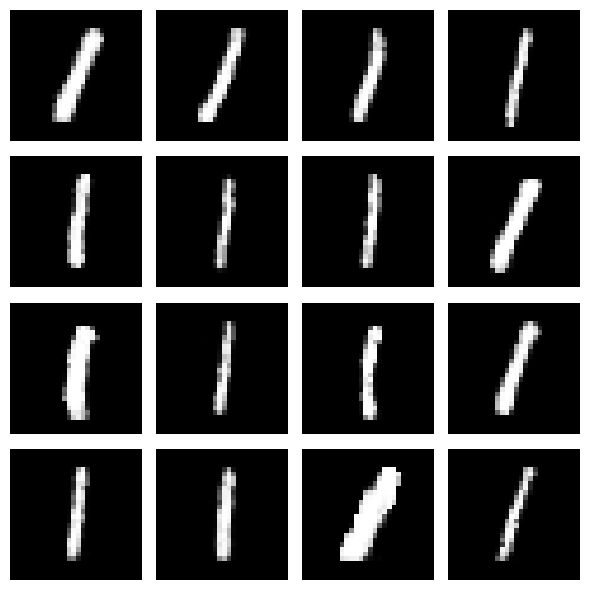

Digit 2


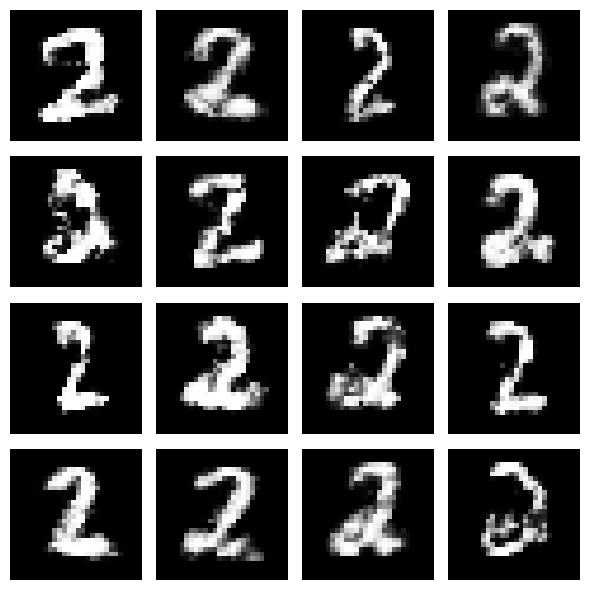

Digit 3


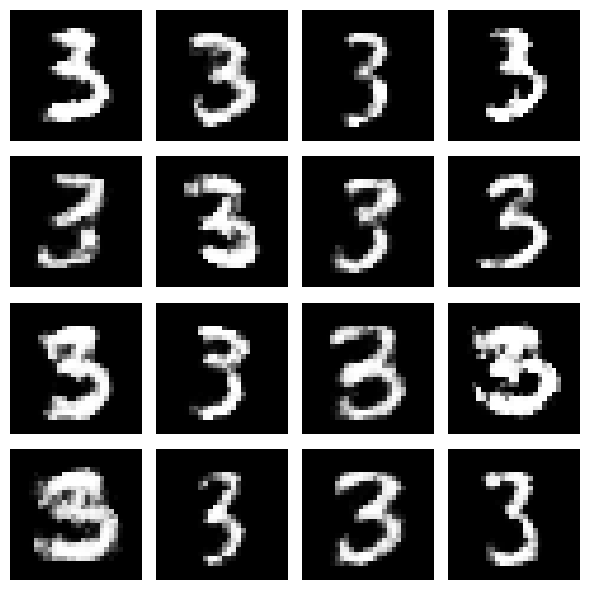

Digit 4


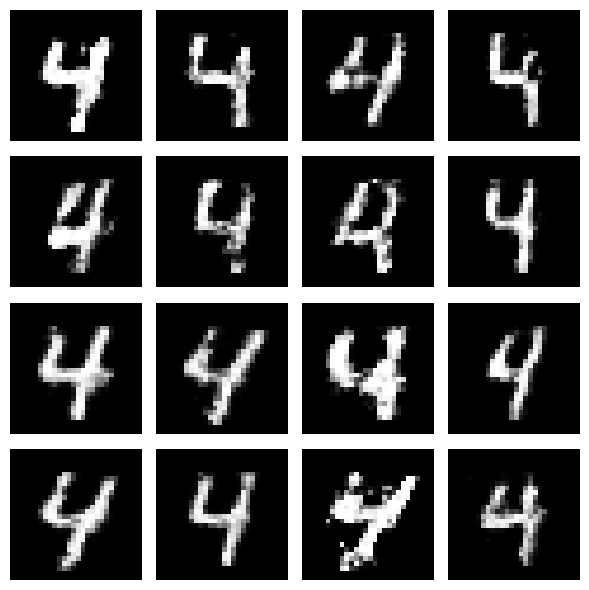

Digit 5


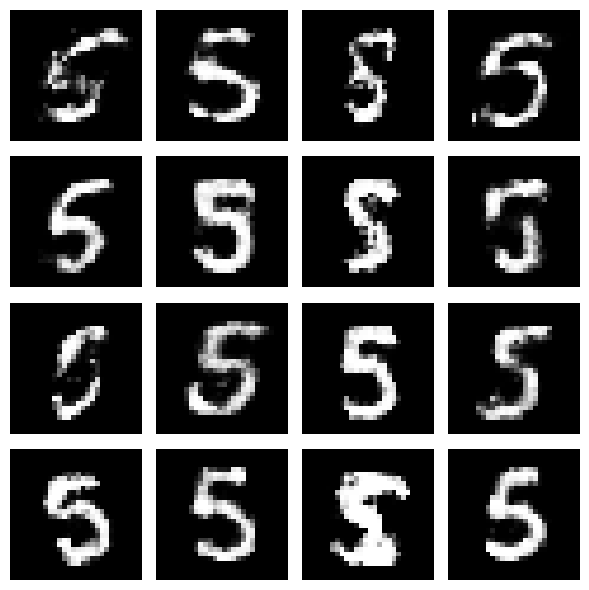

Digit 6


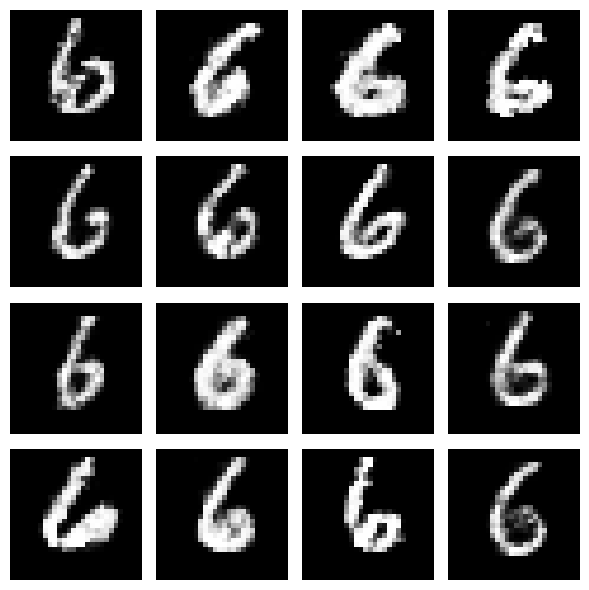

Digit 7


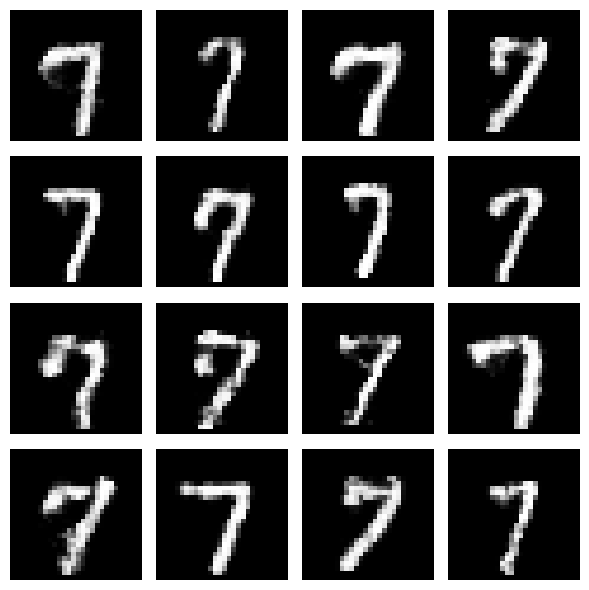

Digit 8


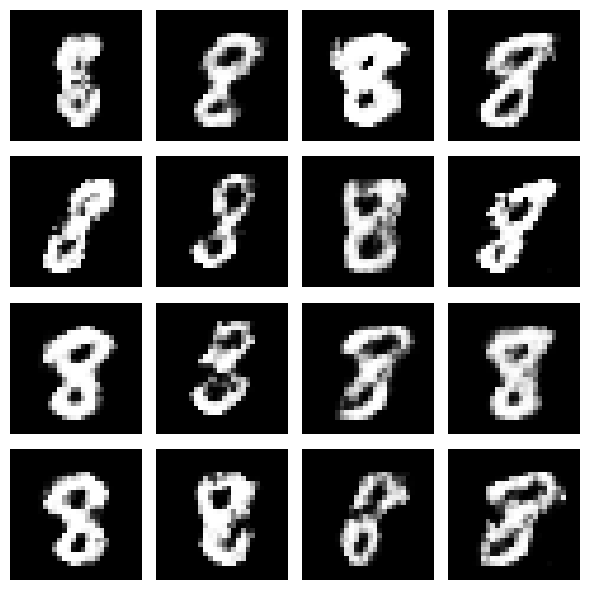

Digit 9


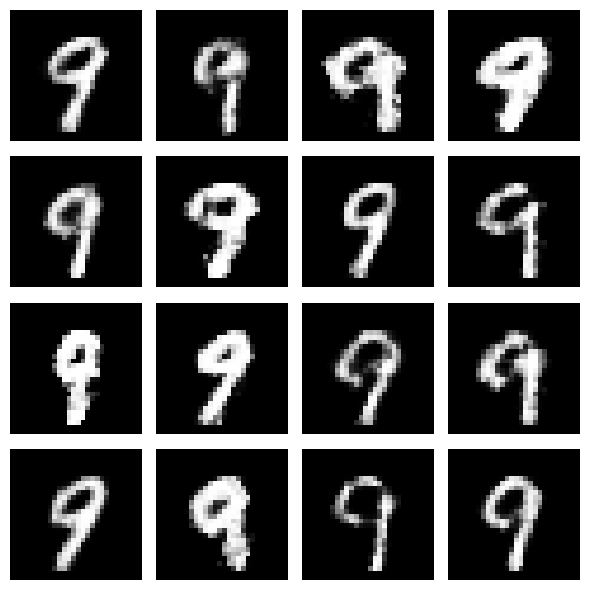

In [9]:
for digit in range(10):
    print(f"Digit {digit}")
    show_cgan_images(G, LATENT_DIM, device, digit=digit)